In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from multiprocessing import Pool

from statsmodels.api import MixedLM
import statsmodels.formula.api as smf
import statsmodels.stats.multitest as smm
from statsmodels.robust.scale import mad
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

from scipy import stats
from scipy.stats import spearmanr

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
Meta = pd.read_csv('../data/Zhu.Metadata.csv', index_col=0)

In [3]:
RawData = pd.read_csv('../data/Zhu.Neurons.Raw.csv', index_col=0)

In [4]:
Zhu_Neurons_filtered = RawData.loc[:, RawData.mean()>=10]

In [5]:
Meta = Meta.loc[Zhu_Neurons_filtered.index]

In [6]:
Zhu_Neurons_filtered.index.name='individualID'

# pyDeSeq2

In [7]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=Zhu_Neurons_filtered,
    metadata=Meta,
    design_factors=['status', 'treatment'],
    continuous_factors=['age'],
    refit_cooks=True,
    inference=inference,
)

/home/kulianov/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
dds.deseq2()

Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 3.04 seconds.

Fitting dispersion trend curve...
... done in 0.66 seconds.

Fitting MAP dispersions...
... done in 3.73 seconds.

Fitting LFCs...
... done in 2.63 seconds.

Refitting 0 outliers.



In [9]:
dds.vst()

Fitting dispersions...
... done in 3.03 seconds.

Fitting dispersion trend curve...
... done in 0.81 seconds.



In [10]:
Deseq_counts = pd.DataFrame(dds.layers['normed_counts'], index=Zhu_Neurons_filtered.index, columns = Zhu_Neurons_filtered.columns)

In [11]:
Deseq_counts.to_csv('../data/Zhu.Neurons.pyDeSeq2.csv')

In [12]:
Deseq_vst = pd.DataFrame(dds.layers['vst_counts'], index=Zhu_Neurons_filtered.index, columns = Zhu_Neurons_filtered.columns)

In [13]:
Deseq_vst.to_csv('../data/Zhu.Neurons.pyDeSeq2.vst.csv')

In [14]:
stat = DeseqStats(dds, contrast=["status", "Schizophrenia", "control"], inference=inference)
stat.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: status Schizophrenia vs control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000076351   40.089961        0.294037  0.135675  2.167207  0.030219   
ENSG00000112584  364.408813       -0.228413  0.135269 -1.688583  0.091299   
ENSG00000110536   22.794220       -0.297992  0.130900 -2.276484  0.022817   
ENSG00000260641   11.529949       -0.071697  0.198881 -0.360501  0.718473   
ENSG00000007541  110.327678        0.030889  0.150625  0.205070  0.837517   
...                     ...             ...       ...       ...       ...   
ENSG00000173166   26.892736       -0.060282  0.149437 -0.403397  0.686656   
ENSG00000272619   19.209844        0.163665  0.151060  1.083448  0.278609   
ENSG00000111877   23.272086        0.385107  0.220031  1.750237  0.080077   
ENSG00000089335  174.178565       -0.302458  0.106620 -2.836770  0.004557   
ENSG00000204947   13.345660       -0.159250  0.212103 -0.750815  0.452764   

     

... done in 1.48 seconds.



In [15]:
stat.results_df.to_csv('../results/DEGs.Diagnosis.csv')

# Gene selection

In [16]:
Deseq_vst.index.name = 'individualID'

In [17]:
Deseq_vst_aggregated = Deseq_vst.groupby(Deseq_vst.index).mean()

In [18]:
Vst_corr = Deseq_vst_aggregated.corrwith(Meta.loc[Deseq_vst_aggregated.index,:].age)

In [19]:
Vst_corr = Vst_corr[Vst_corr.abs() > 0.3]

In [20]:
Preselected_counts = Deseq_vst_aggregated[Vst_corr.index].copy()
Preselected_counts.index.name = 'individualID'
Meta.index.name = 'individualID'

In [21]:
df = Preselected_counts.merge(Meta[['age', 'status', 'treatment']], on='individualID', how='left')

gene='ENSG00000152082'

model = MixedLM.from_formula(f"{gene} ~ age + C(status, Treatment('control'))", df, groups="treatment")
result = model.fit()

print(result.summary())

coef_pval_df = pd.DataFrame()

coef_tmp = pd.DataFrame({gene : result.params})
coef_tmp.index = 'coef_'+coef_tmp.index.astype(str)
coef_tmp = coef_tmp.T
coef_tmp

pval_tmp = pd.DataFrame({gene : result.pvalues})
pval_tmp.index = 'pval_'+pval_tmp.index
pval_tmp = pval_tmp.T
pval_tmp

coef_pval_tmp = pd.concat([coef_tmp, pval_tmp], axis=1)
coef_pval_df = pd.concat([coef_pval_df,coef_pval_tmp])

coef_pval_df

                                  Mixed Linear Model Regression Results
Model:                            MixedLM               Dependent Variable:               ENSG00000152082
No. Observations:                 116                   Method:                           REML           
No. Groups:                       2                     Scale:                            0.1726         
Min. group size:                  56                    Log-Likelihood:                   inf            
Max. group size:                  60                    Converged:                        Yes            
Mean group size:                  58.0                                                                   
---------------------------------------------------------------------------------------------------------
                                                 Coef.    Std.Err.    z    P>|z|    [0.025       0.975]  
--------------------------------------------------------------------------------

/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/ho

,coef_Intercept,"coef_C(status, Treatment('control'))[T.Schizophrenia]",coef_age,coef_treatment Var,pval_Intercept,"pval_C(status, Treatment('control'))[T.Schizophrenia]",pval_age,pval_treatment Var
ENSG00000152082,-6.241474e-17,-0.145705,-0.01288,0.0,1.0,0.058953,9.427106e-07,NaN


In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
def AppendFile(df, gene, file):
    
    with open(file, 'a') as f:
        model = MixedLM.from_formula(f"{gene} ~ age + C(status, Treatment('control'))", df, groups="treatment")
        result = model.fit()
        
        coef_tmp = list(result.params)
        pval_tmp = list(result.pvalues)
        line = [gene]+coef_tmp+pval_tmp
        line = str(line)[1:-1].replace(' ', '')+'\n'
        f.write(line)

In [24]:
%%time

filename = '../results/MLM.Zhu.Neurons.pyDeseq2.vst.txt'

with open(filename, 'w') as f:
    f.write('gene,coef_Intercept,coef_diagnosis,coef_age,coef_Treatment_Var,pval_Intercept,pval_diagnosis,pval_age,pval_Treatment_Var\n')

p = Pool(16)
for gene in df.columns[1:-3]:
    d = [p.apply_async(AppendFile, args=(df, gene, filename))]
p.close()
p.join()

CPU times: user 4.43 s, sys: 875 ms, total: 5.3 s
Wall time: 4min 14s


# Age Score

In [25]:
filename = '../results/MLM.Zhu.Neurons.pyDeseq2.vst.txt'

MLM = pd.read_csv(filename, index_col=0)
MLM.head()

,coef_Intercept,coef_diagnosis,coef_age,coef_Treatment_Var,pval_Intercept,pval_diagnosis,pval_age,pval_Treatment_Var
gene,,,,,,,,
'ENSG00000127540',7.749834,-0.293282,-0.015497,0.222753,9.798919e-205,0.005644,0.000018,0.514187
'ENSG00000108179',6.225118,-0.257756,-0.011833,0.040623,0.000000e+00,0.003089,0.000069,0.623147
'ENSG00000218175',5.803240,-0.281104,-0.012535,0.341007,1.134988e-125,0.001616,0.000037,0.503490
'ENSG00000233928',5.407547,0.150174,0.012367,0.161454,1.676640e-98,0.197624,0.001850,0.525509
'ENSG00000181626',5.185355,0.242344,0.024150,0.036702,3.176113e-72,0.142292,0.000019,0.634085


/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:547: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:402: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:400: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:551: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:554: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/home/kulianov/.local/lib/python3.8/site-packages/pydeseq2/utils.py:547: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)

In [26]:
MLM.index = MLM.index.str.replace('gene_', '').str.replace("'", "")
MLM = MLM.loc[~MLM.pval_age.isna()]

In [27]:
p_values_bh = smm.multipletests(MLM.pval_age, alpha=0.1, method='fdr_bh')[1]
MLM['padj_age']	= p_values_bh

p_values_bh = smm.multipletests(MLM.pval_diagnosis, alpha=0.1, method='fdr_bh')[1]
MLM['padj_diagnosis']	= p_values_bh

In [28]:
MLM_age = MLM.query('padj_age < 0.1')

In [29]:
df_norm = Preselected_counts.copy()
eps = 1e-6

M = df_norm.abs().quantile(0.95, axis=1)
df_norm = df_norm.div(M + eps, axis=0)

MAD = df_norm.apply(lambda row: mad(row, c=1.0), axis=1)
df_norm = df_norm.div(MAD + eps, axis=0)

score_up = df_norm.T.loc[MLM_age.query('coef_age > 0').index].mean(axis=0)
score_down = df_norm.T.loc[MLM_age.query('coef_age < 0').index].mean(axis=0)
age_score = score_up - score_down


In [30]:
age_score.index.name = 'individualID'
df_plot = pd.DataFrame({'age_score':age_score}).merge(Meta, on='individualID')

In [31]:
rho, p = spearmanr(df_plot['age_score'], df_plot['age'], nan_policy='omit')
print('Spearman r=',rho,'p=',p)

Spearman r= 0.6578734282225464 p= 1.029654118352805e-15


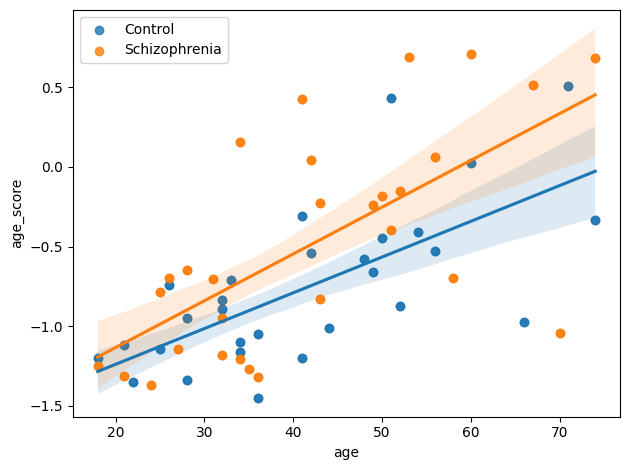

In [32]:
sns.regplot(data=df_plot.loc[:,:].query('status == "control"'), x='age', y='age_score', label='Control')
sns.regplot(data=df_plot.loc[:,:].query('status != "control"'), x='age', y='age_score', label='Schizophrenia')
plt.legend()

plt.tight_layout()
plt.show()
plt.close()

In [33]:
import statsmodels.formula.api as smf

df_plot["age_c"] = df_plot["age"] - df_plot["age"].mean()

model = smf.ols("age_score ~ age_c * C(status, Treatment('control'))", data=df_plot.loc[:,:])
result = model.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:              age_score   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     32.88
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.55e-15
Time:                        10:31:34   Log-Likelihood:                -68.514
No. Observations:                 116   AIC:                             145.0
Df Residuals:                     112   BIC:                             156.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [34]:
result.resid.to_csv('../results/Zhu.Neuron.AgeScore.model.resid.csv')

ShapiroResult(statistic=0.9720344543457031, pvalue=0.015785176306962967)


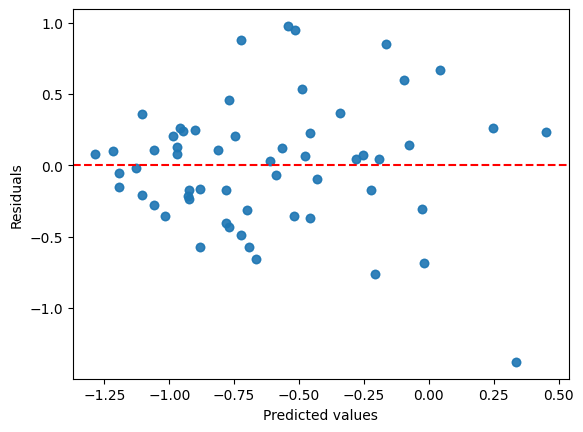

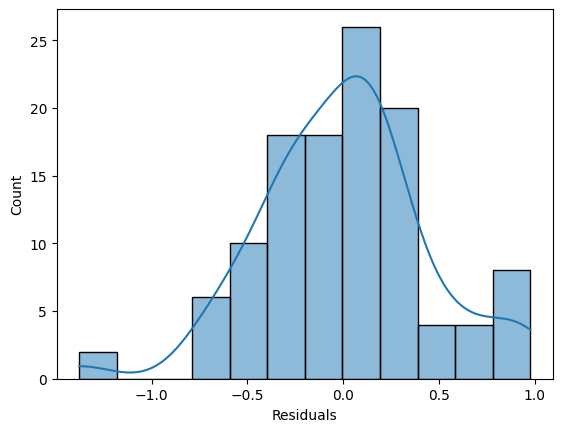

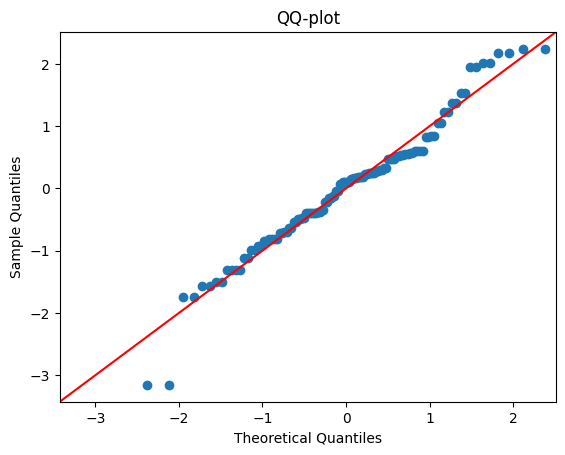

{'Lagrange multiplier statistic': 19.165751816974257, 'p-value': 0.00025264940170079684, 'f-value': 7.389135709657569, 'f p-value': 0.00014607168684284226}


In [35]:
print(stats.shapiro(result.resid))

residuals = result.resid
fitted = result.fittedvalues

plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()
plt.close()

sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.show()
plt.close()

sm.qqplot(result.resid, line="45", fit=True)
plt.title("QQ-plot")
plt.show()
plt.close()

bp_test = het_breuschpagan(residuals, result.model.exog)

labels = ['Lagrange multiplier statistic', 
          'p-value', 
          'f-value', 
          'f p-value']

print(dict(zip(labels, bp_test)))